In [23]:
import tensorflow as tf
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

class LightInvarianceLayer(Layer):
    """
    Adds photometric augmentations for light invariance:
      - Random brightness and contrast during training
      - Optional CLAHE (uses OpenCV) during training
      - Per-image standardization at inference & training end

    Config:
      - brightness_delta: float
      - contrast_lower, contrast_upper: float
      - use_clahe: bool
      - clahe_clip_limit, clahe_tile_grid_size
      - training_only_augment: bool (apply chosen augmentations only during training)
      - preserve_range: whether to assume inputs in [0,1] (True) or [0,255]
    """

    def __init__(self,
                 brightness_delta=0.1,
                 contrast_lower=0.9,
                 contrast_upper=1.1,
                 use_clahe=False,
                 clahe_clip_limit=2.0,
                 clahe_tile_grid_size=(8, 8),
                 training_only_augment=True,
                 preserve_range=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.brightness_delta = float(brightness_delta)
        self.contrast_lower = float(contrast_lower)
        self.contrast_upper = float(contrast_upper)
        self.use_clahe = bool(use_clahe)
        self.clahe_clip_limit = float(clahe_clip_limit)
        self.clahe_tile_grid_size = tuple(clahe_tile_grid_size)
        self.training_only_augment = bool(training_only_augment)
        self.preserve_range = bool(preserve_range)

    def _apply_clahe_numpy(self, img):
        # img expected HWC float32 in [0,1] or [0,255] depending on preserve_range
        import cv2
        import numpy as np
        img_np = img.numpy().astype(np.float32)
        if self.preserve_range:
            # map to [0,255] for CLAHE
            arr = np.clip(img_np * 255.0, 0, 255).astype(np.uint8)
        else:
            arr = np.clip(img_np, 0, 255).astype(np.uint8)

        # If single-channel, apply CLAHE directly; else convert to LAB and apply to L
        if arr.ndim == 2 or arr.shape[2] == 1:
            clahe = cv2.createCLAHE(clipLimit=self.clahe_clip_limit, tileGridSize=self.clahe_tile_grid_size)
            out = clahe.apply(arr.squeeze())
            out = out[..., np.newaxis]
        else:
            lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=self.clahe_clip_limit, tileGridSize=self.clahe_tile_grid_size)
            cl = clahe.apply(l)
            lab = cv2.merge((cl, a, b))
            out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        if self.preserve_range:
            out = out.astype(np.float32) / 255.0
        else:
            out = out.astype(np.float32)

        return out

    def call(self, inputs, training=None):
        # Handle case where training parameter is not passed
        if training is None:
            training = tf.constant(True)  # Default to training mode
        
        def augment(x):
            # x is a float32 tensor with shape [B, H, W, C]
            x_aug = x
            # Random brightness
            x_aug = tf.image.random_brightness(x_aug, max_delta=self.brightness_delta)
            # Random contrast
            x_aug = tf.image.random_contrast(x_aug, lower=self.contrast_lower, upper=self.contrast_upper)
            # option: other photometric transforms could be added (saturation/hue) for RGB
            if self.use_clahe:
                # apply CLAHE per-image using tf.py_function (maps to numpy+cv2)
                def _clahe_fn(img):
                    return tf.py_function(func=self._apply_clahe_numpy, inp=[img], Tout=tf.float32)
                # map_fn over batch
                x_aug = tf.map_fn(_clahe_fn, x_aug, dtype=tf.float32)
            return x_aug

        # If training-only augmentations requested, condition on training
        if self.training_only_augment:
            x = tf.cond(tf.cast(training, tf.bool),
                        lambda: augment(inputs),
                        lambda: inputs)
        else:
            x = augment(inputs)

        # Always do per-image standardization (zero mean, unit variance)
        # But per_image_standardization expects float32
        x = tf.map_fn(lambda im: tf.image.per_image_standardization(im), x)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'brightness_delta': self.brightness_delta,
            'contrast_lower': self.contrast_lower,
            'contrast_upper': self.contrast_upper,
            'use_clahe': self.use_clahe,
            'clahe_clip_limit': self.clahe_clip_limit,
            'clahe_tile_grid_size': self.clahe_tile_grid_size,
            'training_only_augment': self.training_only_augment,
            'preserve_range': self.preserve_range
        })
        return cfg

class FeatureEncryptionLayer(Layer):
    def __init__(self, encryption_strength=0.5, use_random_projection=True, **kwargs):
        super().__init__(**kwargs)
        self.encryption_strength = encryption_strength
        self.use_random_projection = use_random_projection

    def build(self, input_shape):
        # Create learnable encryption matrix
        self.encryption_matrix = self.add_weight(
            name='encryption_matrix',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='random_normal',
            trainable= False
        )
        
        # Create bias for additional obfuscation
        self.encryption_bias = self.add_weight(
            name='encryption_bias',
            shape=(input_shape[-1],),
            initializer='random_normal',
            trainable= False
        )
        
        self.random_projection = self.add_weight(
            name='random_projection',
            shape=(input_shape[-1], input_shape[-1]),
            initializer='random_normal',
            trainable= False
        )
    def call(self, inputs, training=None):

        if self.encryption_strength == 0:
            return inputs
        encrypted = tf.matmul(inputs, self.encryption_matrix) + self.encryption_bias
        encrypted = tf.matmul(encrypted, self.random_projection)
        if training:
            noise = tf.random.normal(tf.shape(encrypted), stddev=1)  # Add noise
            encrypted += noise
        encrypted = tf.nn.tanh(encrypted)
        mixed = (1 - self.encryption_strength) * inputs + self.encryption_strength * encrypted
        return mixed
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'encryption_strength': self.encryption_strength,
            'use_random_projection': self.use_random_projection
        })
        return config

class GaussianNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, stddev, training_only=True, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
        self.training_only = training_only
    
    def call(self, inputs, training=None):
        noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
        return inputs + noise
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'stddev': self.stddev,
            'training_only': self.training_only
        })
        return config
    
class GaussianBlur(Layer):
    def __init__(self, kernel_size=5, sigma=1.0, **kwargs):
        super(GaussianBlur, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.sigma = sigma

    def build(self, input_shape):
        ax = tf.range(-self.kernel_size // 2 + 1, self.kernel_size // 2 + 1, dtype=tf.float32)
        xx, yy = tf.meshgrid(ax, ax)
        kernel = tf.exp(-(xx**2 + yy**2) / (2. * self.sigma**2))
        kernel = kernel / tf.reduce_sum(kernel)
        kernel = tf.expand_dims(kernel, axis=-1)
        kernel = tf.expand_dims(kernel, axis=-1)
        kernel = tf.repeat(kernel, input_shape[-1], axis=-1)
        self.kernel = tf.Variable(kernel, trainable=False)

    def call(self, x):
        return tf.nn.depthwise_conv2d(x, self.kernel, strides=[1, 1, 1, 1], padding='SAME')

class WeightNoiseLayer(tf.keras.layers.Layer):
    def __init__(self, stddev, **kwargs):
        super().__init__(**kwargs)
        self.stddev = stddev
    
    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(tf.shape(inputs), mean=0.0, stddev=self.stddev)
            return inputs * noise
        return inputs
    
    def get_config(self):
        config = super().get_config()
        config.update({'stddev': self.stddev})
        return config

class PrivacyPreservingUNet:
    def __init__(self, 
                 input_size=(None, None, 1), 
                 target_size=(128, 128), 
                 num_classes=4,
                 privacy_config=None):
        """
        Privacy-preserving U-Net using only native TensorFlow/Keras
        
        Args:
            privacy_config: dict with privacy settings
                - 'gradient_clipping': float, gradient clipping value (default: 1.0)
                - 'input_noise': float, input perturbation level (default: 0.01)
                - 'weight_noise': float, weight noise injection (default: 0.001)
                - 'privacy_dropout': float, enhanced dropout for privacy (default: 0.2)
                - 'feature_noise': bool, add noise to intermediate features
        """
        self.input_size = input_size
        self.target_size = target_size
        self.num_classes = num_classes
        
        # Default privacy configuration
        self.privacy_config = {
            'gradient_clipping': 1.0,
            'input_noise': 0.01,
            'weight_noise': 0.001,
            'privacy_dropout': 0.2,
            'feature_noise':0.005,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        }
        
        if privacy_config:
            self.privacy_config.update(privacy_config)

        print("Privacy configuration:")
        for key, value in self.privacy_config.items():
            print(f"  {key}: {value}")
    
    def add_gaussian_noise_layer(self, x, noise_stddev=0.01, training_only=True, name="noise"):
        """Add Gaussian noise layer for privacy protection"""
        return GaussianNoiseLayer(stddev=noise_stddev, training_only=training_only, name=name)(x)
    
    def add_encryption_layer(self, x, layer_name):
        """Add appropriate encryption layer based on configuration"""
        if not self.privacy_config.get('feature_encryption', False):
            return x
        print("added Encryption layer")
        return FeatureEncryptionLayer(
            encryption_strength=self.privacy_config.get('encryption_strength'),
            use_random_projection=True,
            name=f"{layer_name}_encryption"
        )(x)
    
    def privacy_aware_conv_block(self, x, feature_noise, filters, block_name, dropout_rate=0.1):
        """Convolutional block with privacy-enhancing modifications"""
        # First convolution
        conv = Conv2D(filters, (3, 3), activation='relu', padding='same', 
                     kernel_initializer='he_normal', 
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     name=f"{block_name}_conv1")(x)
        
        # Add feature noise for privacy
        if feature_noise > 0:
            conv = self.add_gaussian_noise_layer(
                conv, noise_stddev=feature_noise, name=f"{block_name}_feature_noise1"
            )
        
        conv = BatchNormalization(name=f"{block_name}_bn1")(conv)
        
        # Second convolution
        conv = Conv2D(filters, (3, 3), activation='relu', padding='same', 
                     kernel_initializer='he_normal',
                     kernel_regularizer=tf.keras.regularizers.l2(0.001),
                     name=f"{block_name}_conv2")(conv)
        
        if self.privacy_config.get('feature_encryption', False):
            conv = self.add_encryption_layer(conv, f"{block_name}_conv2")
       
        
        if feature_noise > 0:
            conv = self.add_gaussian_noise_layer(
                conv, noise_stddev= feature_noise, name=f"{block_name}_feature_noise2"
            )
        
        conv = BatchNormalization(name=f"{block_name}_bn2")(conv)
        
        # Enhanced dropout for privacy
        privacy_dropout = max(dropout_rate, self.privacy_config.get('privacy_dropout'))
        if privacy_dropout > 0:
            conv = Dropout(privacy_dropout, name=f"{block_name}_dropout")(conv)
        
        return conv
    
    def add_weight_noise_layer(self, x, noise_stddev=0.001, name="weight_noise"):
        """Add noise to simulate weight perturbation"""
        return WeightNoiseLayer(stddev=noise_stddev, name=name)(x)
    
    def build_model(self):
        inputs = Input(self.input_size, name="input_layer")
        
        # Optional input noise for privacy
        gaussuian_blur = self.privacy_config.get('gaussian_blur', True)
        input_noise_stddev = self.privacy_config.get('input_noise', 0.01)
        drop_out_rate = self.privacy_config.get('privacy_dropout')
        add_feature_noise = self.privacy_config.get('feature_noise', False)
        feature_noise = self.privacy_config.get('feature_noise', 0.005)
        
        print(f"Adding input noise with stddev: {input_noise_stddev}, dropout rate: {drop_out_rate}, feature noise: {add_feature_noise}")

        
        x = tf.keras.layers.Resizing(self.target_size[0], self.target_size[1], name="resize")(inputs)
        x = tf.keras.layers.Rescaling(1./255, name="rescale")(x)

        use_light = self.privacy_config.get('use_light_augment', True)
        if use_light:
            print("Adding light invariance layer")
            light_layer = LightInvarianceLayer(
                brightness_delta=self.privacy_config.get('brightness_delta', 0.08),
                contrast_lower=self.privacy_config.get('contrast_lower', 0.9),
                contrast_upper=self.privacy_config.get('contrast_upper', 1.1),
                use_clahe=self.privacy_config.get('use_clahe', False),
                clahe_clip_limit=self.privacy_config.get('clahe_clip_limit', 2.0),
                clahe_tile_grid_size=self.privacy_config.get('clahe_tile_grid_size', (8, 8)),
                training_only_augment=self.privacy_config.get('light_training_only', True),
                preserve_range=True,
                name="light_invariance"
            )
            x = light_layer(x)


        if gaussuian_blur:
            x = GaussianBlur(name="gaussian_blur")(x)

        if self.privacy_config.get('input_noise', 0) > 0:
            x = self.add_gaussian_noise_layer(x, noise_stddev=input_noise_stddev , name="input_noise")
        
        # Block 1

        c1 = self.privacy_aware_conv_block(x, feature_noise= feature_noise,  filters=32, block_name="encoder_block1", 
                                          dropout_rate= drop_out_rate)
        p1 = MaxPooling2D((2, 2), name="pool1")(c1)

        # Block 2
        c2 = self.privacy_aware_conv_block(p1, feature_noise= feature_noise, filters=64, block_name="encoder_block2", 
                                          dropout_rate=drop_out_rate)
        p2 = MaxPooling2D((2, 2), name="pool2")(c2)

        # Block 3
        c3 = self.privacy_aware_conv_block(p2, feature_noise= feature_noise, filters=128, block_name="encoder_block3", 
                                          dropout_rate=drop_out_rate)
        p3 = MaxPooling2D((2, 2), name="pool3")(c3)

        # Bottleneck
        c4 = self.privacy_aware_conv_block(p3, feature_noise= feature_noise, filters=256, block_name="bottleneck", 
                                          dropout_rate=drop_out_rate)
        
        # Add weight noise to bottleneck if configured
        weight_noise = self.privacy_config.get('weight_noise', 0.001)
        
        if self.privacy_config.get('weight_noise', 0) > 0:
            c4 = self.add_weight_noise_layer(c4, noise_stddev=weight_noise, 
                                           name="bottleneck_weight_noise")
        # Block 5
        u5 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same', name="upsample5")(c4)
        u5 = concatenate([u5, c3], name="concat5")
        c5 = self.privacy_aware_conv_block(u5, feature_noise= feature_noise, filters=128, block_name="decoder_block5", 
                                          dropout_rate=drop_out_rate)

        # Block 6
        u6 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', name="upsample6")(c5)
        u6 = concatenate([u6, c2], name="concat6")
        c6 = self.privacy_aware_conv_block(u6, feature_noise= feature_noise, filters=64, block_name="decoder_block6", 
                                          dropout_rate=drop_out_rate)

        # Block 7
        u7 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', name="upsample7")(c6)
        u7 = concatenate([u7, c1], name="concat7")
        c7 = self.privacy_aware_conv_block(u7, feature_noise= feature_noise, filters=32, block_name="decoder_block7", 
                                          dropout_rate=drop_out_rate)
        

        # Output layer
        outputs = Conv2D(self.num_classes, (1, 1), activation='softmax', name="output_layer")(c7)

        model = Model(inputs, outputs, name="privacy_preserving_unet")
        return model
    @staticmethod
    def load_model(model_path):
        """
        Load a pre-trained model with custom objects
        """
        custom_objects = {
            'GaussianBlur': GaussianBlur,
            'GaussianNoiseLayer': GaussianNoiseLayer,
            'WeightNoiseLayer': WeightNoiseLayer,
            'FeatureEncryptionLayer': FeatureEncryptionLayer,
            'LightInvarianceLayer': LightInvarianceLayer,
            'dice_coefficient_multiclass': dice_coefficient_multiclass,
            'iou_metric_multiclass': iou_metric_multiclass
        }
        return tf.keras.models.load_model(model_path, custom_objects=custom_objects)
       

# Custom optimizer with gradient noise and clipping
class PrivacyAwareOptimizer:
    def __init__(self, base_optimizer, gradient_noise_stddev=0.1, gradient_clip_value=1.0):
        self.base_optimizer = base_optimizer
        self.gradient_noise_stddev = gradient_noise_stddev
        self.gradient_clip_value = gradient_clip_value
    
    def get_optimizer(self):
        """Get optimizer with privacy-preserving modifications"""
        # Note: This is a conceptual implementation
        # In practice, you would need to implement custom training loop
        return self.base_optimizer

# Custom training function with privacy techniques
def train_with_privacy_techniques(model, train_data, val_data, privacy_config, 
                                 epochs=100, batch_size=32):
    """
    Custom training function with privacy-preserving techniques
    """

    img_train, label_train = train_data
    
    # Compile model with privacy-aware settings
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=privacy_config.get('gradient_clipping', 1.0)  # Gradient clipping
    )


    model.compile(
        optimizer=optimizer,
        loss= 'sparse_categorical_crossentropy',
        metrics=['accuracy', dice_coefficient_multiclass, iou_metric_multiclass]
    )
    
    # Custom callbacks for privacy
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5),
    ]
    
    
    print("Privacy-preserving training configuration:")
    for key, value in privacy_config.items():
        print(f"  {key}: {value}")
    
    history = model.fit(
        img_train, label_train,
        validation_data=val_data,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
    )
    
    return history

def dice_coefficient_multiclass(y_true, y_pred, smooth=1e-6):
        """Dice coefficient for multi-class segmentation with sparse labels"""
        # Convert sparse labels to one-hot if needed
        if len(y_true.shape) != len(y_pred.shape):
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
            y_true = tf.cast(y_true, tf.float32)
        
        # Flatten tensors
        y_true_f = tf.reshape(y_true, [-1, tf.shape(y_true)[-1]])
        y_pred_f = tf.reshape(y_pred, [-1, tf.shape(y_pred)[-1]])
        
        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
        union = tf.reduce_sum(y_true_f, axis=0) + tf.reduce_sum(y_pred_f, axis=0)
        dice = (2. * intersection + smooth) / (union + smooth)
        
        return tf.reduce_mean(dice)

def dice_loss_multiclass(y_true, y_pred, smooth=1e-6):
    """Dice loss for multi-class segmentation"""
    return 1 - dice_coefficient_multiclass(y_true, y_pred, smooth)

# IoU Metric for multi-class
def iou_metric_multiclass(y_true, y_pred, smooth=1e-6):
    # Convert predictions to class labels
    y_pred = tf.argmax(y_pred, axis=-1)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true = tf.cast(y_true, tf.float32)

    # Flatten
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(tf.cast(y_true_f == y_pred_f, tf.float32))
    union = tf.cast(tf.size(y_true_f, out_type=tf.int32), tf.float32)

    return (intersection + smooth) / (union + smooth)


# Improved Learning Rate Scheduler
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    elif epoch < 20:
        return lr * 0.5
    else:
        return lr * 0.1

# Factory function for different privacy levels


In [15]:
def create_lightweight_privacy_unet(privacy_level="medium"):
    """
    Create U-Net with different privacy levels using only native TensorFlow
    """
    privacy_configs = {
        "low": {
            'input_noise': 0.005,
            'privacy_dropout': 0.1,
            'gradient_clipping': 2.0,
            'feature_noise': 0.005,
            'feature_encryption': False,
        },
        "medium": {
            'gradient_clipping': 1.0,
            'input_noise': 0.1,
            'weight_noise': 0.1,
            'privacy_dropout': 0.2,
            'feature_noise': 0.1,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        },
        "high": {
            'gradient_clipping': 0.5,
            'input_noise': 0.9,
            'weight_noise': 0.9,
            'privacy_dropout': 0.2,
            'feature_noise': 0.9,
            'feature_encryption': True,
            'encryption_strength': 0.9,
        }
    }
    
    config = privacy_configs.get(privacy_level, privacy_configs["medium"])
    
    privacy_unet = PrivacyPreservingUNet(
        input_size=(None, None, 1),
        target_size=(128, 128),
        num_classes=4,
        privacy_config=config
    )
    
    model = privacy_unet.build_model()
    
    return model, config

In [16]:
import os

def load_images_label_pairs(images , labels, image_dir, label_dir, step=1, step_size=1000, add_noise=False):
    image_files = sorted(os.listdir(image_dir))  # Sort to maintain consistency
    label_files = sorted(os.listdir(label_dir))

    images =[]
    labels=[]

    # currupted_images = [2355, 2365, 2366]
    print("Images count: " + str(len(image_files)))
    for img, label in zip(image_files[step * step_size: (step + 1) * step_size], label_files[step * step_size: (step + 1) * step_size]):
        # print("Processing image: " + img + " with label: " + label)
        img_path = os.path.join(image_dir, img)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Adjust if images are colored
        if add_noise == True:
            noise = np.random.normal(loc=0, scale=10, size=img.shape).astype(np.float32)
            img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
        img = cv2.resize(img, (128, 128))
        images.append(img)


        label_path = os.path.join(label_dir, label)
        label = np.load(label_path)
        label = cv2.resize(label, (128, 128))  # Resize to match the image size
        labels.append(label)

    # return images, labels
    return np.array(images), np.array(labels)

In [17]:
image_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images'
label_dir_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/labels'


images = []
labels = []

images, labels = load_images_label_pairs(images , labels , image_dir_path, label_dir_path, step=0, step_size=10000, add_noise=True)

Images count: 27431


In [12]:
from sklearn.model_selection import train_test_split

model_medium, config = create_lightweight_privacy_unet(privacy_level="high")

img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)

for layer_names in model_medium.layers:
    print(layer_names.name)
history = train_with_privacy_techniques(model=model_medium, 
                              train_data=(img_train, label_train), 
                              val_data=(img_test, label_test), 
                              privacy_config=config, 
                              epochs=50, 
                              batch_size=8)

dice_history = history.history['dice_coefficient_multiclass']
iou_history  = history.history['iou_metric_multiclass']

print("Train Dice (each epoch):", dice_history)
print("Train IoU  (each epoch):", iou_history)

# If you want the final epoch only:
print("Final train Dice:", dice_history[-1])
print("Final train IoU :",  iou_history[-1])

# The same keys prefixed with 'val_' hold your validation curves
print("Final val Dice:", history.history['val_dice_coefficient_multiclass'][-1])
print("Final val IoU :", history.history['val_iou_metric_multiclass'][-1])


model_medium.save('privacy_preserving_unet_medium_light_invariance.h5')

Privacy configuration:
  gradient_clipping: 0.5
  input_noise: 0.9
  weight_noise: 0.9
  privacy_dropout: 0.2
  feature_noise: 0.9
  feature_encryption: True
  encryption_strength: 0.9
Adding input noise with stddev: 0.9, dropout rate: 0.2, feature noise: 0.9
Adding light invariance layer
input_layer
resize
rescale
light_invariance
gaussian_blur
input_noise
encoder_block1_conv1
encoder_block1_feature_noise1
encoder_block1_bn1
encoder_block1_conv2
encoder_block1_conv2_encryption
encoder_block1_feature_noise2
encoder_block1_bn2
encoder_block1_dropout
pool1
encoder_block2_conv1
encoder_block2_feature_noise1
encoder_block2_bn1
encoder_block2_conv2
encoder_block2_conv2_encryption
encoder_block2_feature_noise2
encoder_block2_bn2
encoder_block2_dropout
pool2
encoder_block3_conv1
encoder_block3_feature_noise1
encoder_block3_bn1
encoder_block3_conv2
encoder_block3_conv2_encryption
encoder_block3_feature_noise2
encoder_block3_bn2
encoder_block3_dropout
pool3
bottleneck_conv1
bottleneck_feature_n

2025-08-14 23:59:07.422122: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 96 bytes spill stores, 96 bytes spill loads



 999/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3264 - dice_coefficient_multiclass: 0.1753 - iou_metric_multiclass: 0.3264 - loss: 3.2259

2025-08-15 00:00:04.338976: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion_9', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion_7', 4 bytes spill stores, 4 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion_4', 4 bytes spill stores, 4 bytes spill loads



1000/1000 ━━━━━━━━━━━━━━━━━━━━ 106s 60ms/step - accuracy: 0.3266 - dice_coefficient_multiclass: 0.1753 - iou_metric_multiclass: 0.3266 - loss: 3.2241 - val_accuracy: 0.6274 - val_dice_coefficient_multiclass: 0.2251 - val_iou_metric_multiclass: 0.6274 - val_loss: 1.1721 - learning_rate: 1.0000e-04
Epoch 2/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step - accuracy: 0.6653 - dice_coefficient_multiclass: 0.2354 - iou_metric_multiclass: 0.6653 - loss: 1.0565 - val_accuracy: 0.8254 - val_dice_coefficient_multiclass: 0.2666 - val_iou_metric_multiclass: 0.8254 - val_loss: 0.6921 - learning_rate: 1.0000e-04
Epoch 3/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 48s 48ms/step - accuracy: 0.8127 - dice_coefficient_multiclass: 0.2657 - iou_metric_multiclass: 0.8127 - loss: 0.7075 - val_accuracy: 0.8431 - val_dice_coefficient_multiclass: 0.2746 - val_iou_metric_multiclass: 0.8431 - val_loss: 0.5971 - learning_rate: 1.0000e-04
Epoch 4/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 56s 56ms/step - accuracy: 0.8365 - dice_coef

Train Dice (each epoch): [0.19209888577461243, 0.24590836465358734, 0.2683590054512024, 0.27459749579429626, 0.3080497086048126, 0.3566206693649292, 0.38129156827926636, 0.4050805866718292, 0.4267825186252594, 0.4420616924762726, 0.45186761021614075, 0.4607917070388794, 0.46883782744407654, 0.4775542616844177, 0.48554250597953796, 0.4932296872138977, 0.49992483854293823, 0.5069111585617065, 0.5138168931007385, 0.5192455649375916, 0.5246685743331909, 0.5267766714096069, 0.528800904750824, 0.5309402346611023, 0.5336520671844482, 0.5360056161880493, 0.5383382439613342, 0.5410557389259338, 0.541606605052948, 0.5424423813819885, 0.5437963008880615, 0.5447988510131836, 0.5457236766815186, 0.5474360585212708, 0.54738849401474, 0.5495523810386658, 0.5492575764656067, 0.5519061088562012, 0.5523102283477783, 0.5530153512954712, 0.5542336702346802, 0.5544704794883728, 0.5554908514022827, 0.5560593008995056, 0.5568746328353882, 0.5569993853569031, 0.5576168298721313]
Train IoU  (each epoch): [0.40

Original image shape: (400, 640)


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Predicted mask shape: (128, 128)


(-0.5, 127.5, 127.5, -0.5)

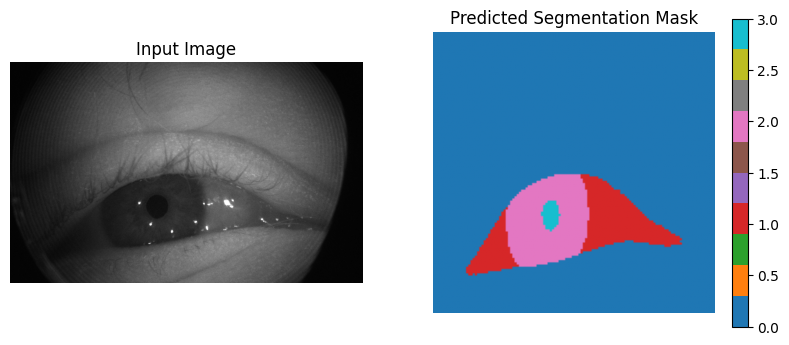

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

image_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images/008110.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

custom_objects = {
            'GaussianBlur': GaussianBlur,
            'GaussianNoiseLayer': GaussianNoiseLayer,
            'WeightNoiseLayer': WeightNoiseLayer,
            'FeatureEncryptionLayer': FeatureEncryptionLayer,
            'LightInvarianceLayer': LightInvarianceLayer,
            'dice_coefficient_multiclass': dice_coefficient_multiclass,
            'iou_metric_multiclass': iou_metric_multiclass,
        }
model = tf.keras.models.load_model("privacy_preserving_unet_medium_light_invariance.h5", custom_objects=custom_objects)


# Step 4: Predict with the model
pred = model.predict(img_input)  # Output shape: (1, 128, 128, 4) due to resizing inside model

# Step 5: Convert softmax to class labels
predicted_mask = np.argmax(pred, axis=-1)[0]  # Shape: (128, 128)
print("Predicted mask shape:", predicted_mask.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
plt.title("Predicted Segmentation Mask")
plt.colorbar()
plt.axis('off')


Original image shape: (400, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Original image shape: (400, 640)
[[-7.11054802e-02 -1.35779381e-04 -2.81654596e-02 ...  4.10526991e-02
  -6.47459030e-02 -6.00645542e-02]
 [ 6.41374588e-02 -7.84647465e-02  4.82311249e-02 ... -3.35130692e-02
   3.88535261e-02 -6.31874800e-03]
 [-1.48316264e-01 -1.54616833e-02 -8.59484673e-02 ... -1.02336407e-01
   2.01286077e-02  1.42943859e-03]
 ...
 [ 2.57745981e-02  1.47057891e-01 -7.40804672e-02 ... -5.32566309e-02
   6.23351336e-02  3.97878885e-02]
 [-2.52317190e-02  3.03897858e-02  3.41494083e-02 ...  4.89819050e-02
  -6.19434118e-02 -7.25667477e-02]
 [ 4.33523655e-02 -8.62574577e-03  6.63858652e-02 ... -1.13595724e-01
  -2.30994225e-02 -3.88166904e-02]]


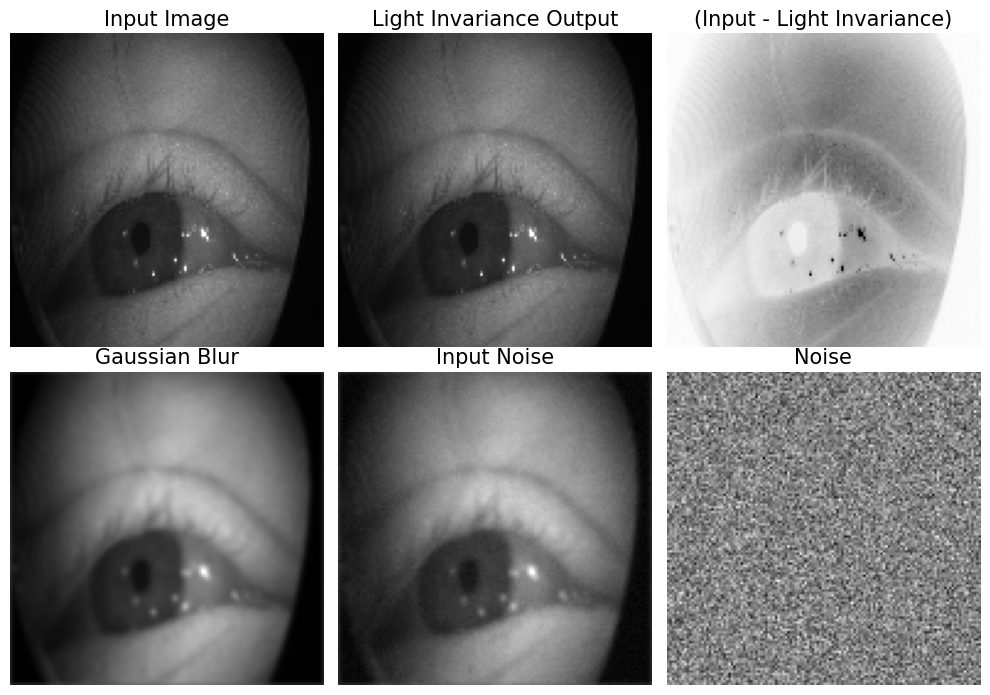

In [34]:
layer_names = ["resize","rescale", "light_invariance", "gaussian_blur", "input_noise"]

outputs = [model.get_layer(name).output for name in layer_names]
multi_out_model = tf.keras.Model(inputs=model.input, outputs=outputs)

image_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images/008110.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)

resize, rescale, out_light, blur , input_noise= multi_out_model.predict(img_input)

out_light = out_light[0, :, :, 0]  # Remove batch and channel dims
blur = blur[0, :, :, 0]  # Remove batch and channel dims
input_noise = input_noise[0, :, :, 0]  # Remove batch and channel dims

image_path = '/home/yasas/GazeEstimation/openEDS/openEDS/train/images/008110.png'

image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print("Original image shape:", image.shape)
img_input = np.expand_dims(image, axis=(0, -1))  # e.g., (1, 240, 320, 1)
img_input = tf.image.resize(img_input, (128, 128))  # Resize to match model input
img_input = img_input / 255.0  # Rescale to [0, 1] if needed

img_input = img_input[0, :, :, 0]


deffernce = img_input - out_light
noise = input_noise - blur

print(noise)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))  # 2 rows, 3 columns
axes = axes.ravel()  # flatten 2D array of axes for easy indexing

images = [
    (img_input, "Input Image"),
    (out_light, "Light Invariance Output"),
    (deffernce, "(Input - Light Invariance)"),
    (blur, "Gaussian Blur"),
    (input_noise, "Input Noise"),
    (noise, "Noise")
]

for ax, (img, title) in zip(axes, images):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=15)
    ax.axis('off')

plt.tight_layout()
plt.show()

fig.savefig("comparison.png")

In [ ]:
import cv2
import numpy as np
from tqdm import tqdm

# Path to your video file
video_path = 'eye_test.mp4'

# Open the video file
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Store predicted masks for each frame
predicted_masks = []

for _ in tqdm(range(frame_count), desc="Processing frames"):
    ret, frame = cap.read()
    if not ret:
        break
    # Convert to grayscale if needed
    if len(frame.shape) == 3:
        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        frame_gray = frame

    # Prepare input for model: (1, H, W, 1)
    img_input = np.expand_dims(frame_gray, axis=(0, -1))
    # Predict using the loaded model
    pred = model.predict(img_input)
    predicted_mask = np.argmax(pred, axis=-1)[0]  # Shape: (128, 128)
    predicted_masks.append(predicted_mask)

    print("Predicted mask shape:", predicted_mask.shape)

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(predicted_mask, cmap='tab10', vmin=0, vmax=3)
    plt.title("Input Image")
    plt.axis('off')

    

cap.release()

# Convert list to numpy array if needed
predicted_masks = np.array(predicted_masks)
print("Predicted masks shape:", predicted_masks.shape)

In [19]:
privacy_configs = {
        
        "medium_1": {
            'gradient_clipping': 1.0,
            'input_noise': 0.05,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'feature_noise': 0.05,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        },
        "medium_2": {
            'gradient_clipping': 1.0,
            'input_noise': 0.10,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'feature_noise': 0.05,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        },
        "medium_3": {
            'gradient_clipping': 1.0,
            'input_noise': 0.30,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'feature_noise': 0.05,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        },
        "medium_4": {
            'gradient_clipping': 1.0,
            'input_noise': 0.50,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'feature_noise': 0.05,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        },
        "medium_5": {
            'gradient_clipping': 1.0,
            'input_noise': 0.70,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'feature_noise': 0.05,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        },
        "medium_6": {
            'gradient_clipping': 1.0,
            'input_noise': 0.90,
            'weight_noise': 0.01,
            'privacy_dropout': 0.2,
            'feature_noise': 0.05,
            'feature_encryption': True,
            'encryption_strength': 0.5,
        }
    }

def create_lightweight_privacy_with_different_noise_unet(config):
    
    privacy_unet = PrivacyPreservingUNet(
        input_size=(None, None, 1),
        target_size=(128, 128),
        num_classes=4,
        privacy_config=config
    )
    
    model = privacy_unet.build_model()
    
    return model, config

   

def evaluate_tarining_configs(privacy_configs):

    dice_results = {}
    iou_results = {} 

    for privacy_level in reversed(list(privacy_configs.keys())):
        print(f"Training model with privacy level: {privacy_level}")
        
        model, config = create_lightweight_privacy_with_different_noise_unet(privacy_configs[privacy_level])
        
        img_train, img_test, label_train, label_test = train_test_split(images, labels, test_size=0.2, random_state=42)
        
        history = train_with_privacy_techniques(model=model, 
                                    train_data=(img_train, label_train), 
                                    val_data=(img_test, label_test), 
                                    privacy_config=config, 
                                    epochs=50, 
                                    batch_size=8)
        
        model.save(f'privacy_preserving_unet_{privacy_level}.h5')

        dice_history = history.history['dice_coefficient_multiclass']
        iou_history  = history.history['iou_metric_multiclass'] 
        print(f"Final train Dice for {privacy_level}:", dice_history[-1])
        print(f"Final train IoU for {privacy_level} :",  iou_history[-1])
        # Store final dice coefficient for each privacy level

        dice_results[privacy_level] = dice_history[-1]
        iou_results[privacy_level] = iou_history[-1]

    print(dice_results)
    print(iou_results)


In [ ]:
import tensorflow as tf
import numpy as np

layer = FeatureEncryptionLayer(encryption_strength=1.0, use_random_projection=False)
x = tf.random.normal((1, 4))
y1 = layer(x)  # baseline output

# Manually modify weights
new_matrix = tf.eye(4) * 10.0
layer.encryption_matrix.assign(new_matrix)
layer.encryption_bias.assign(tf.ones(4))

y2 = layer(x)  # output after weight modification

print("Before:", y1.numpy())
print("After :", y2.numpy())


Before: [[-0.40329176  0.0973305  -0.5398183   0.7845356 ]]
After : [[-1.8703263 -1.8817439  3.9334846 10.096877 ]]


In [ ]:
import tensorflow as tf
import numpy as np

layer = FeatureEncryptionLayer(encryption_strength=.7, use_random_projection=True)
x = tf.ones((1, 4))
print(x)
y1 = layer(x)  # baseline output

# Manually modify weights
new_matrix = tf.eye(4) * 10.0
layer.encryption_matrix.assign(new_matrix)
layer.encryption_bias.assign(tf.ones(4))

y2 = layer(x)  # output after weight modification

print("Before:", y1.numpy())
print("After :", y2.numpy())

tf.Tensor([[1. 1. 1. 1.]], shape=(1, 4), dtype=float32)
Before: [[0.2033035  0.31314924 0.29200974 0.24666329]]
After : [[ 1.0116539   0.03800267  1.6692815  -0.01282224]]


In [ ]:
privacy_configs_encriptions = {
        
        "medium_1": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.6,
        },
        "medium_2": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.7,
        },
        "medium_3": {
            'gradient_clipping': 0.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.8,
        },
        "medium_4": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.90,
        },
        "medium_5": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.90,
        },
        "medium_6": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.95,
        },
        "medium_7": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.97,
        },
        "medium_8": {
            'gradient_clipping': 1.0,
            'input_noise': 0.0,
            'weight_noise': 0.0,
            'privacy_dropout': 0.0,
            'feature_noise': 0.0,
            'feature_encryption': True,
            'encryption_strength': 0.99,
        }
    }


evaluate_tarining_configs(privacy_configs_encriptions)

Training model with privacy level: medium_6
Privacy configuration:
  gradient_clipping: 1.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.98
Adding input noise with stddev: 0.0, dropout rate: 0.0, feature noise: 0.0
Adding light invariance layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
Privacy-preserving training configuration:
  gradient_clipping: 1.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.98
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 77s 52ms/step - accuracy: 0.3382 - dice_coefficient_multiclass: 0.1764 - iou_metric_multiclass: 0.3382 - loss: 3.1459 - val_accuracy: 0.6601 - val_dice_coefficient_multiclass: 0.2329 - val_iou_metric_multiclass: 0.6601 - val_loss: 1.0511 - learning_rate: 1

Final train Dice for medium_6: 0.39339837431907654
Final train IoU for medium_6 : 0.8591618537902832
Training model with privacy level: medium_5
Privacy configuration:
  gradient_clipping: 1.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.9
Adding input noise with stddev: 0.0, dropout rate: 0.0, feature noise: 0.0
Adding light invariance layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
Privacy-preserving training configuration:
  gradient_clipping: 1.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.9
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.3719 - dice_coefficient_multiclass: 0.1863 - iou_metric_multiclass: 0.3719 - loss: 3.0994 - val_accuracy: 0.8495 - val_dice_coeff

Final train Dice for medium_5: 0.9350840449333191
Final train IoU for medium_5 : 0.9870898723602295
Training model with privacy level: medium_4
Privacy configuration:
  gradient_clipping: 1.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.8
Adding input noise with stddev: 0.0, dropout rate: 0.0, feature noise: 0.0
Adding light invariance layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
Privacy-preserving training configuration:
  gradient_clipping: 1.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.8
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.5598 - dice_coefficient_multiclass: 0.2590 - iou_metric_multiclass: 0.5598 - loss: 2.8667 - val_accuracy: 0.8495 - val_dice_coeffi

Final train Dice for medium_4: 0.9246925115585327
Final train IoU for medium_4 : 0.9859118461608887
Training model with privacy level: medium_3
Privacy configuration:
  gradient_clipping: 0.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.6
Adding input noise with stddev: 0.0, dropout rate: 0.0, feature noise: 0.0
Adding light invariance layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
added Encryption layer
Privacy-preserving training configuration:
  gradient_clipping: 0.0
  input_noise: 0.0
  weight_noise: 0.0
  privacy_dropout: 0.0
  feature_noise: 0.0
  feature_encryption: True
  encryption_strength: 0.6
Epoch 1/50
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.6917 - dice_coefficient_multiclass: 0.3200 - iou_metric_multiclass: 0.6917 - loss: 2.7792 - val_accuracy: 0.9264 - val_dice_coeffi

KeyboardInterrupt: 

In [ ]:
privacy_configs_encriptions = {
        "medium_1": {
            'gaussian_blur': False,
            'gradient_clipping': 100.0,
            'input_noise': 0,
            'weight_noise': 0.5,
            'privacy_dropout': 0,
            'feature_noise': 0,
            'feature_encryption': True,
            'encryption_strength': 0,
        },
        "medium_2": {
            'gaussian_blur': False,
            'gradient_clipping': 100.0,
            'input_noise': 0,
            'weight_noise': 1,
            'privacy_dropout': 0,
            'feature_noise': 0,
            'feature_encryption': False,
            'encryption_strength': 0,
        },
        "medium_3": {
            'gaussian_blur': False,
            'gradient_clipping': 100.0,
            'input_noise': 0,
            'weight_noise': 9,
            'privacy_dropout': 0,
            'feature_noise': 0,
            'feature_encryption': False,
            'encryption_strength': 0,
        },
        "medium_4": {
            'gaussian_blur': False,
            'gradient_clipping': 100.0,
            'input_noise': 0,
            'weight_noise': 8,
            'privacy_dropout': 0,
            'feature_noise': 0,
            'feature_encryption': False,
            'encryption_strength': 0,
        },
        "medium_5": {
            'gaussian_blur': False,
            'gradient_clipping': 100.0,
            'input_noise': 0,
            'weight_noise': 7,
            'privacy_dropout': 0,
            'feature_noise': 0,
            'feature_encryption': False,
            'encryption_strength': 0,
        },
        "medium_6": {
            'gaussian_blur': False,
            'gradient_clipping': 100.0,
            'input_noise': 0,
            'weight_noise': 0,
            'privacy_dropout': 0,
            'feature_noise': 6,
            'feature_encryption': False,
            'encryption_strength': 0,
        }
    }


evaluate_tarining_configs(privacy_configs_encriptions)

In [13]:
import tensorflow as tf
import numpy as np

# Sample input: batch of 1, 32x32 image with 64 channels (e.g., after a conv block)
sample_input = tf.random.normal((1, 32, 32, 64))

# Test at different strengths
for strength in [0.0, 0.5, 1.0]:
    layer = FeatureEncryptionLayer(encryption_strength=strength, use_random_projection=True)
    output = layer(sample_input)
    print(f"Strength {strength}: Mean={tf.reduce_mean(output):.4f}, Std={tf.math.reduce_std(output):.4f}")
    print(f"Cosine similarity to original: {tf.reduce_mean(tf.keras.losses.cosine_similarity(sample_input, output, axis=-1)):.4f}")

Strength 0.0: Mean=0.0029, Std=0.1552
Cosine similarity to original: -0.0125
Strength 0.5: Mean=-0.0027, Std=0.1595
Cosine similarity to original: -0.0007
Strength 1.0: Mean=-0.0017, Std=0.1622
Cosine similarity to original: 0.0055
